<a href="https://colab.research.google.com/github/KrunalVaghela62/sedrica_updates/blob/main/ViT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
"""
A series of helper functions used throughout the course.

If a function gets defined once and could be used over and over, it'll go in here.
"""
import torch
import matplotlib.pyplot as plt
import numpy as np

from torch import nn

import os
import zipfile

from pathlib import Path

import requests

# Walk through an image classification directory and find out how many files (images)
# are in each subdirectory.
import os

def walk_through_dir(dir_path):
    """
    Walks through dir_path returning its contents.
    Args:
    dir_path (str): target directory

    Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
    """
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())


# Plot linear data or training and test and predictions (optional)
def plot_predictions(
    train_data, train_labels, test_data, test_labels, predictions=None
):
    """
  Plots linear training data and test data and compares predictions.
  """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})


# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc


def print_train_time(start, end, device=None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format).
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"\nTrain time on {device}: {total_time:.3f} seconds")
    return total_time


# Plot loss curves of a model
def plot_loss_curves(results):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """
    loss = results["train_loss"]
    test_loss = results["test_loss"]

    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()


# Pred and plot image function from notebook 04
# See creation: https://www.learnpytorch.io/04_pytorch_custom_datasets/#113-putting-custom-image-prediction-together-building-a-function
from typing import List
import torchvision


def pred_and_plot_image(
    model: torch.nn.Module,
    image_path: str,
    class_names: List[str] = None,
    transform=None,
    device: torch.device = "cuda" if torch.cuda.is_available() else "cpu",
):
    """Makes a prediction on a target image with a trained model and plots the image.

    Args:
        model (torch.nn.Module): trained PyTorch image classification model.
        image_path (str): filepath to target image.
        class_names (List[str], optional): different class names for target image. Defaults to None.
        transform (_type_, optional): transform of target image. Defaults to None.
        device (torch.device, optional): target device to compute on. Defaults to "cuda" if torch.cuda.is_available() else "cpu".

    Returns:
        Matplotlib plot of target image and model prediction as title.

    Example usage:
        pred_and_plot_image(model=model,
                            image="some_image.jpeg",
                            class_names=["class_1", "class_2", "class_3"],
                            transform=torchvision.transforms.ToTensor(),
                            device=device)
    """

    # 1. Load in image and convert the tensor values to float32
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

    # 2. Divide the image pixel values by 255 to get them between [0, 1]
    target_image = target_image / 255.0

    # 3. Transform if necessary
    if transform:
        target_image = transform(target_image)

    # 4. Make sure the model is on the target device
    model.to(device)

    # 5. Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
        # Add an extra dimension to the image
        target_image = target_image.unsqueeze(dim=0)

        # Make a prediction on image with an extra dimension and send it to the target device
        target_image_pred = model(target_image.to(device))

    # 6. Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # 7. Convert prediction probabilities -> prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # 8. Plot the image alongside the prediction and prediction probability
    plt.imshow(
        target_image.squeeze().permute(1, 2, 0)
    )  # make sure it's the right size for matplotlib
    if class_names:
        title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    else:
        title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    plt.title(title)
    plt.axis(False)

def set_seeds(seed: int=42):
    """Sets random sets for torch operations.

    Args:
        seed (int, optional): Random seed to set. Defaults to 42.
    """
    # Set the seed for general torch operations
    torch.manual_seed(seed)
    # Set the seed for CUDA torch operations (ones that happen on the GPU)
    torch.cuda.manual_seed(seed)

def download_data(source: str,
                  destination: str,
                  remove_source: bool = True) -> Path:
    """Downloads a zipped dataset from source and unzips to destination.

    Args:
        source (str): A link to a zipped file containing data.
        destination (str): A target directory to unzip data to.
        remove_source (bool): Whether to remove the source after downloading and extracting.

    Returns:
        pathlib.Path to downloaded data.

    Example usage:
        download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                      destination="pizza_steak_sushi")
    """
    # Setup path to data folder
    data_path = Path("data/")
    image_path = data_path / destination

    # If the image folder doesn't exist, download it and prepare it...
    if image_path.is_dir():
        print(f"[INFO] {image_path} directory exists, skipping download.")
    else:
        print(f"[INFO] Did not find {image_path} directory, creating one...")
        image_path.mkdir(parents=True, exist_ok=True)

        # Download pizza, steak, sushi data
        target_file = Path(source).name
        with open(data_path / target_file, "wb") as f:
            request = requests.get(source)
            print(f"[INFO] Downloading {target_file} from {source}...")
            f.write(request.content)

        # Unzip pizza, steak, sushi data
        with zipfile.ZipFile(data_path / target_file, "r") as zip_ref:
            print(f"[INFO] Unzipping {target_file} data...")
            zip_ref.extractall(image_path)

        # Remove .zip file
        if remove_source:
            os.remove(data_path / target_file)

    return image_path

In [1]:
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12 or int(torch.__version__.split(".")[0]) == 2, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

torch version: 2.6.0+cu124
torchvision version: 0.21.0+cu124


In [2]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

[INFO] Couldn't find torchinfo... installing it.
[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.
Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4393, done.
remote: Counting objects: 100% (1534/1534), done.
remote: Compressing objects: 100% (135/135), done.
remote: Total 4393 (delta 1458), reused 1399 (delta 1399), pack-reused 2859 (from 2)
Receiving objects: 100% (4393/4393), 650.71 MiB | 23.38 MiB/s, done.
Resolving deltas: 100% (2660/2660), done.
Updating files: 100% (248/248), done.


In [3]:
image_path=download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                         destination="pizza_steak_sushi"
                         )
image_path

[INFO] Did not find data/pizza_steak_sushi directory, creating one...
[INFO] Downloading pizza_steak_sushi.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip...
[INFO] Unzipping pizza_steak_sushi.zip data...


PosixPath('data/pizza_steak_sushi')

In [4]:
train_dir=image_path/"train"
test_dir=image_path/"test"

In [5]:
img_size=224
manual_tranforms=transforms.Compose([
    transforms.Resize((img_size,img_size)),
    transforms.ToTensor(),
])

In [6]:
batch_size=32
train_dataloader,test_dataloader,class_names=data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_tranforms,
    batch_size=batch_size
)
class_names

['pizza', 'steak', 'sushi']

In [7]:
#visualising a single image
image_batch,label_batch=next(iter(train_dataloader))
image=image_batch[0]
label=label_batch[0]
image.shape,label

(torch.Size([3, 224, 224]), tensor(0))

Text(0.5, 1.0, 'pizza')

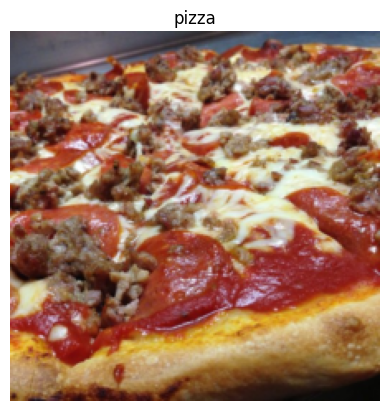

In [8]:
plt.imshow(image.permute(1,2,0)) # rearrange image dimensions to suit matplotlib [color_channels, height, width] -> [height, width, color_channels]
plt.axis(False)
plt.title(class_names[label])

In [9]:
height=224
width=224
patch_res=16
num_channels=3
num_patches=int((height*width)/(patch_res)**2)
num_patches

196

In [10]:
input_image_shape=(height,width,num_channels)
patch_shape=(num_patches,(patch_res**2)*num_channels)
input_image_shape,patch_shape

((224, 224, 3), (196, 768))

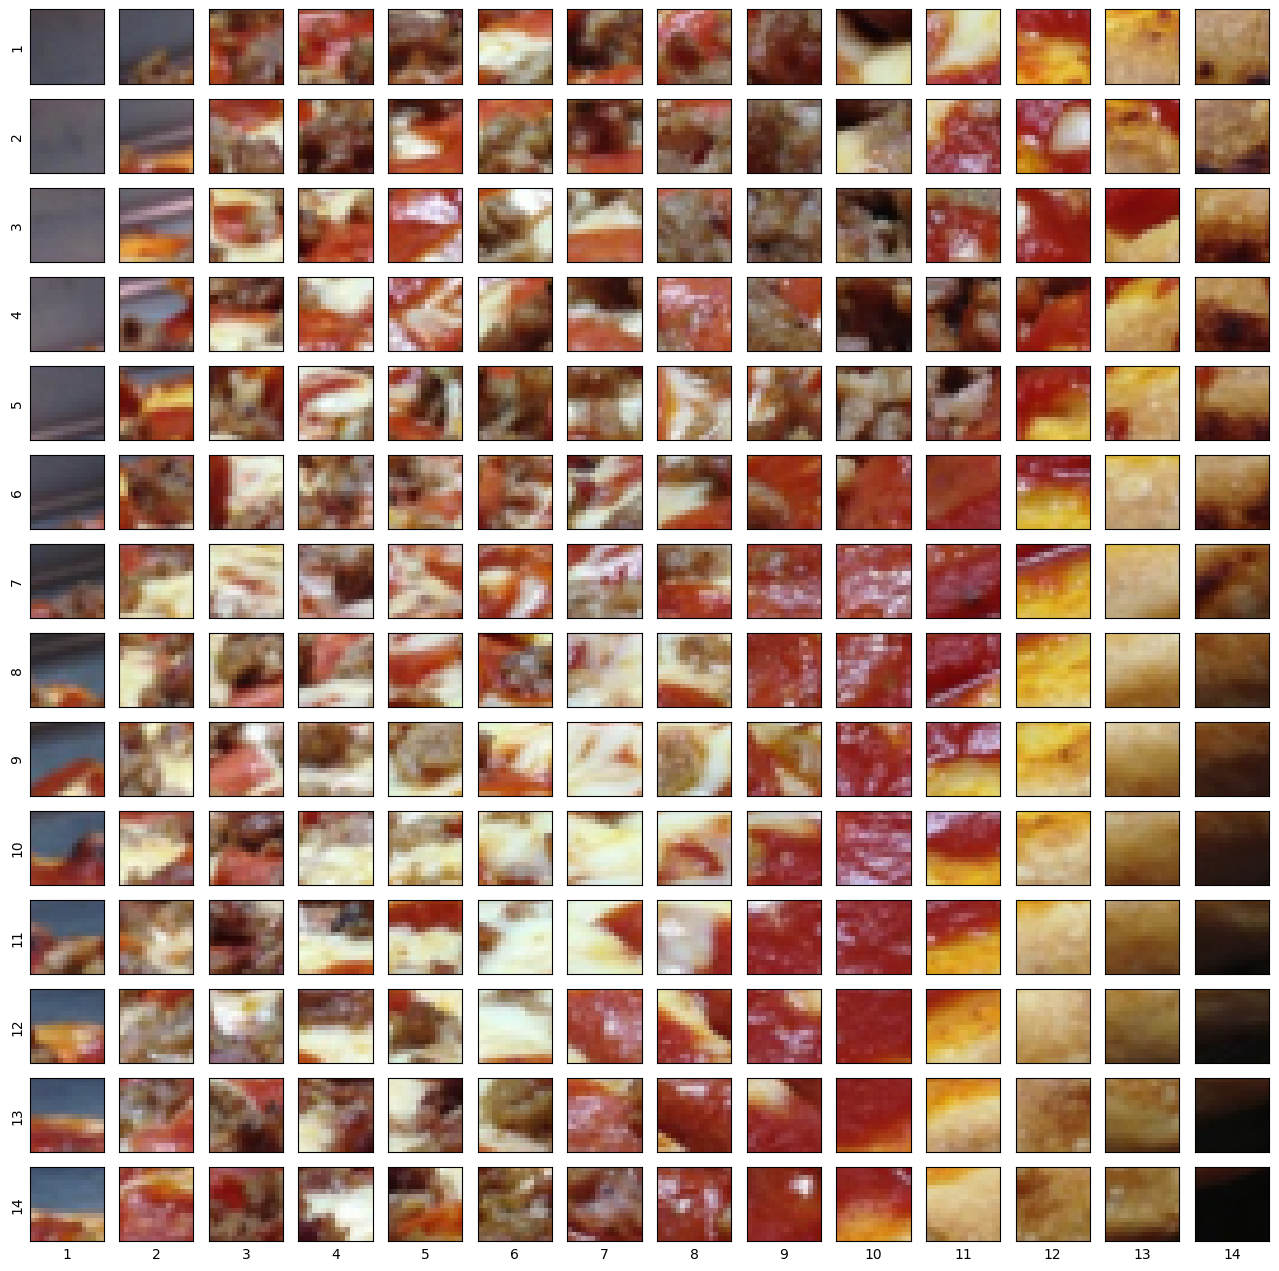

In [11]:
fig,axs=plt.subplots(nrows=int(img_size/patch_res),ncols=int(img_size/patch_res),figsize=(patch_res,patch_res))
image_permuted=image.permute(1,2,0)
for i,patch_h in enumerate(range(0,img_size,patch_res)):
  for j,patch_w in enumerate(range(0,img_size,patch_res)):
    axs[i,j].imshow(image_permuted[patch_w:patch_w+patch_res,patch_h:patch_h+patch_res,:])
    axs[i,j].set_xlabel(j+1)
    axs[i,j].set_ylabel(i+1)
    axs[i,j].set_xticks([])
    axs[i,j].set_yticks([])
    axs[i, j].label_outer()


In [12]:
## each patch is converted to a Dsized vector so from where does each entry in vector comes from??
##a kernel of size patch_size,patch_size is slided over image with stride o patch_size....so for each operation between patch and kernel we have 1 scalar
##hence we apply D differnel kernels to patch to get D sized vector
from torch import nn
D=768
conv2d=nn.Conv2d(
    in_channels=3,
    out_channels=D,
    kernel_size=patch_res,
    stride=patch_res,
    padding=0
)

In [13]:
patch_embedding=conv2d(image.unsqueeze(0))

In [14]:
print(patch_embedding.shape)

torch.Size([1, 768, 14, 14])


Showing random convolutional feature maps from indexes: [500, 289, 390, 532, 573]


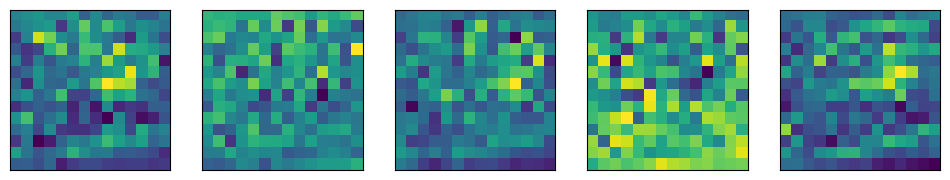

In [15]:
###output of each kernel operation so fix index of embedding vector...here ramdomly fixing embedding vector
# Plot random 5 convolutional feature maps
import random
random_indexes = random.sample(range(0, 758), k=5) # pick 5 numbers between 0 and the embedding size
print(f"Showing random convolutional feature maps from indexes: {random_indexes}")

# Create plot
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(12, 12))

# Plot random image feature maps
for i, idx in enumerate(random_indexes):
    image_conv_feature_map = patch_embedding[:, idx, :, :] # index on the output tensor of the convolutional layer
    axs[i].imshow(image_conv_feature_map.squeeze().detach().numpy())
    axs[i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[]);

In [16]:
# Create flatten layer
flatten = nn.Flatten(start_dim=2, # flatten feature_map_height (dimension 2)
                     end_dim=3) # flatten feature_map_width (dimension 3)

#[1,D,H,W]-->[1,D,H*W]...for each patch a vector of dimension D


In [17]:
class PatchEmbedding(nn.Module):
  def __init__(self,in_channels:int=3,patch_size:int=16,embedding_dim:int=768):
    super().__init__()
    self.conv2d=nn.Conv2d(
        in_channels=in_channels,
        out_channels=embedding_dim,
        kernel_size=patch_size,
        stride=patch_size,
        padding=0
    )
    self.flatten = nn.Flatten(start_dim=2, # flatten feature_map_height (dimension 2)
                     end_dim=3)
  def forward(self,x):
    x=self.conv2d(x)
    x=self.flatten(x)
    x=x.permute(0,2,1)
    return x

Input image shape: torch.Size([1, 3, 224, 224])


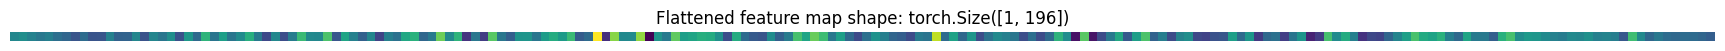

In [18]:
set_seeds()
patchify=PatchEmbedding(in_channels=3,
                          patch_size=16,
                          embedding_dim=768)
print(f"Input image shape: {image.unsqueeze(0).shape}")
patch_embedded_image = patchify(image.unsqueeze(0)) # add an extra batch dimension on the 0th index, otherwise will error
single_flattend_embedded_vector=patch_embedded_image[:,:,1]
plt.figure(figsize=(22, 22))
plt.imshow(single_flattend_embedded_vector.detach().numpy())
plt.title(f"Flattened feature map shape: {single_flattend_embedded_vector.shape}")
plt.axis(False);

Text(0.5, 1.0, 'pizza')

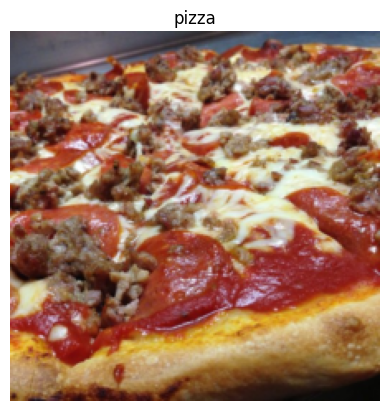

In [19]:
plt.imshow(image.permute(1,2,0)) # rearrange image dimensions to suit matplotlib [color_channels, height, width] -> [height, width, color_channels]
plt.axis(False)
plt.title(class_names[label])

In [20]:
#preparing learnable embedding for the class token
batch_size=patch_embedded_image.shape[0]
D=patch_embedded_image.shape[-1]
class_token=nn.Parameter(torch.randn(batch_size,1,D),requires_grad=True)
class_token.shape

torch.Size([1, 1, 768])

In [21]:
patch_embedded_image_with_class_token=torch.cat((class_token,patch_embedded_image),dim=1)
print(patch_embedded_image_with_class_token.shape)


torch.Size([1, 197, 768])


In [22]:
##creating position embedding
position_embedding=nn.Parameter(torch.randn(1,num_patches+1,D),requires_grad=True)
patch_position_class_embed=patch_embedded_image_with_class_token+position_embedding
patch_position_class_embed.shape

torch.Size([1, 197, 768])

In [23]:
##given x find Z0using eq1

patch_res=16
num_channels=3
height,width=image.shape[1],image.shape[2]
num_patches=int((height*width)/(patch_res)**2)

x=image.unsqueeze(0)

patch_embedding=PatchEmbedding(in_channels=3,
                          patch_size=16,
                         embedding_dim=768)

image_patch_embedded=patch_embedding(x)

batch_size=patch_embedded_image.shape[0]
D=patch_embedded_image.shape[-1]
class_token=nn.Parameter(torch.randn(batch_size,1,D),requires_grad=True)


patch_embedded_image_with_class_token=torch.cat((class_token,image_patch_embedded),dim=1)


position_embedding=nn.Parameter(torch.randn(1,num_patches+1,D),requires_grad=True)
patch_position_class_embed=patch_embedded_image_with_class_token+position_embedding

In [24]:
class MultiheadSelfAttentionBlock(nn.Module):
  def __init__(self,
               embedding_dim:int=768,
               num_heads:int=12,
               attn_dropout:float=0
               ):
    super().__init__()
    self.layer_norm=nn.LayerNorm(embedding_dim)
    self.multihd_atn=nn.MultiheadAttention(embed_dim=embedding_dim,
                                           num_heads=num_heads,
                                           dropout=attn_dropout,
                                           batch_first=True
                                           )
  def forward(self,x):
    x=self.layer_norm(x)
    x,_=self.multihd_atn(query=x,key=x,value=x,need_weights=False)
    return x

In [25]:
multi_head_self_attention=MultiheadSelfAttentionBlock(embedding_dim=768,
                                                            num_heads=12)
patchify_plus_attention = multi_head_self_attention(patch_position_class_embed)

In [26]:
class MLPBlock(nn.Module):
  def __init__(self,
               embedding_dim:int=768,
               mlp_size:int=3072,
               dropout:int=0.1):##The MLP block in ViT upsamples (or expands) the 768-dimensional embedding vector to 3072 dimensions
               ##using the first linear layer, applies a non-linearity (like GELU), and then downsamples it back to 768 using the second linear layer.
    super().__init__()
    self.layer_norm=nn.LayerNorm(embedding_dim)
    self.mlp=nn.Sequential(
        nn.Linear(in_features=embedding_dim,
                  out_features=mlp_size),
        nn.GELU(),
        nn.Dropout(p=dropout),
        nn.Linear(in_features=mlp_size,
                  out_features=embedding_dim),
        nn.Dropout(p=dropout)

    )
  def forward(self,x):
    x=self.layer_norm(x)
    x=self.mlp(x)
    return x

In [27]:

# Create an instance of MLPBlock
mlp_block = MLPBlock(embedding_dim=768, # from Table 1
                     mlp_size=3072, # from Table 1
                     dropout=0.1) # from Table 3
patched_msa_mlp=mlp_block(patchify_plus_attention)
patched_msa_mlp.shape

torch.Size([1, 197, 768])

In [28]:
class TransformerEncoderBlock(nn.Module):
  def __init__(self,embedding_dim:int=768, # Hidden size D from Table 1 for ViT-Base
                 num_heads:int=12, # Heads from Table 1 for ViT-Base
                 mlp_size:int=3072, # MLP size from Table 1 for ViT-Base
                 mlp_dropout:float=0.1, # Amount of dropout for dense layers from Table 3 for ViT-Base
                 attn_dropout:float=0):
    super().__init__()
    self.msa=MultiheadSelfAttentionBlock(embedding_dim=embedding_dim,
                                                     num_heads=num_heads,
                                                     attn_dropout=attn_dropout)
    self.mlp=MLPBlock(embedding_dim=embedding_dim,
                                   mlp_size=mlp_size,
                                   dropout=mlp_dropout)
  def forward(self,x):
    x=self.msa(x)+x
    x=self.mlp(x)+x
    return x


In [29]:
transformer_encoder_block=TransformerEncoderBlock()

In [30]:
class ViT(nn.Module):
  def __init__(self,img_size:int=224, # Training resolution from Table 3 in ViT paper
                 in_channels:int=3, # Number of channels in input image
                 patch_size:int=16, # Patch size
                 num_transformer_layers:int=12, # Layers from Table 1 for ViT-Base
                 embedding_dim:int=768, # Hidden size D from Table 1 for ViT-Base
                 mlp_size:int=3072, # MLP size from Table 1 for ViT-Base
                 num_heads:int=12, # Heads from Table 1 for ViT-Base
                 attn_dropout:float=0, # Dropout for attention projection
                 mlp_dropout:float=0.1, # Dropout for dense/MLP layers
                 embedding_dropout:float=0.1, # Dropout for patch and position embeddings
                 num_classes:int=1000):
    super().__init__()
    self.num_patches=(img_size*img_size)/(patch_size)**2
    self.patchify=PatchEmbedding(in_channels=in_channels,
                          patch_size=patch_size,
                          embedding_dim=embedding_dim)
    self.class_token=nn.Parameter(torch.randn(batch_size,1,D),requires_grad=True)
    self.position_embedding=nn.Parameter(torch.randn(1,num_patches+1,D),requires_grad=True)

    self.embedding_dropout=nn.Dropout(p=embedding_dropout)
    self.encoder=nn.Sequential(
        *[TransformerEncoderBlock(embedding_dim=embedding_dim,num_heads=num_heads,
                                  mlp_size=mlp_size,
                                  mlp_dropout=mlp_dropout) for _ in range(num_transformer_layers)]
    )
    self.classifier=nn.Sequential(
        nn.LayerNorm(embedding_dim),
        nn.Linear(in_features=embedding_dim,
                  out_features=num_classes)
    )
  def forward(self,x):
    batch_size=x.shape[0]
    x=self.patchify(x)
    class_token = self.class_token.expand(batch_size, -1, -1) # "-1" means to infer the dimension (try this line on its own)
    x=torch.cat((class_token,x),dim=1)
    x=x+self.position_embedding

    x=self.encoder(x)

    x=self.classifier(x[:,0])

    return x






In [31]:

set_seeds()

# Create a random tensor with same shape as a single image
random_image_tensor = torch.randn(1, 3, 224, 224) # (batch_size, color_channels, height, width)

# Create an instance of ViT with the number of classes we're working with (pizza, steak, sushi)
vit = ViT(num_classes=len(class_names))

# Pass the random image tensor to our ViT instance
vit(random_image_tensor)

tensor([[0.3899, 0.0727, 0.2997]], grad_fn=<AddmmBackward0>)

In [32]:

from torchinfo import summary

# # Print a summary of our custom ViT model using torchinfo (uncomment for actual output)
summary(model=vit,
         input_size=(32, 3, 224, 224), # (batch_size, color_channels, height, width)
         #col_names=["input_size"], # uncomment for smaller output
         col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"])



Layer (type (var_name))                                 Input Shape          Output Shape         Param #              Trainable
ViT (ViT)                                               [32, 3, 224, 224]    [32, 3]              152,064              True
├─PatchEmbedding (patchify)                             [32, 3, 224, 224]    [32, 196, 768]       --                   True
│    └─Conv2d (conv2d)                                  [32, 3, 224, 224]    [32, 768, 14, 14]    590,592              True
│    └─Flatten (flatten)                                [32, 768, 14, 14]    [32, 768, 196]       --                   --
├─Sequential (encoder)                                  [32, 197, 768]       [32, 197, 768]       --                   True
│    └─TransformerEncoderBlock (0)                      [32, 197, 768]       [32, 197, 768]       --                   True
│    │    └─MultiheadSelfAttentionBlock (msa)           [32, 197, 768]       [32, 197, 768]       2,363,904            True
│    

In [33]:
%%writefile going_modular/engine.py
"""
Contains functions for training and testing a PyTorch model.
"""
import torch

from tqdm.auto import tqdm
from typing import Dict, List, Tuple

def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device) -> Tuple[float, float]:
  """Trains a PyTorch model for a single epoch.

  Turns a target PyTorch model to training mode and then
  runs through all of the required training steps (forward
  pass, loss calculation, optimizer step).

  Args:
    model: A PyTorch model to be trained.
    dataloader: A DataLoader instance for the model to be trained on.
    loss_fn: A PyTorch loss function to minimize.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    device: A target device to compute on (e.g. "cuda" or "cpu").

  Returns:
    A tuple of training loss and training accuracy metrics.
    In the form (train_loss, train_accuracy). For example:

    (0.1112, 0.8743)
  """
  # Put model in train mode
  model.train()

  # Setup train loss and train accuracy values
  train_loss, train_acc = 0, 0

  # Loop through data loader data batches
  for batch, (X, y) in enumerate(dataloader):
      # Send data to target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      y_pred = model(X)

      # 2. Calculate  and accumulate loss
      loss = loss_fn(y_pred, y)
      train_loss += loss.item()

      # 3. Optimizer zero grad
      optimizer.zero_grad()

      # 4. Loss backward
      loss.backward()

      # 5. Optimizer step
      optimizer.step()

      # Calculate and accumulate accuracy metric across all batches
      y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
      train_acc += (y_pred_class == y).sum().item()/len(y_pred)

  # Adjust metrics to get average loss and accuracy per batch
  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc

def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device) -> Tuple[float, float]:
  """Tests a PyTorch model for a single epoch.

  Turns a target PyTorch model to "eval" mode and then performs
  a forward pass on a testing dataset.

  Args:
    model: A PyTorch model to be tested.
    dataloader: A DataLoader instance for the model to be tested on.
    loss_fn: A PyTorch loss function to calculate loss on the test data.
    device: A target device to compute on (e.g. "cuda" or "cpu").

  Returns:
    A tuple of testing loss and testing accuracy metrics.
    In the form (test_loss, test_accuracy). For example:

    (0.0223, 0.8985)
  """
  # Put model in eval mode
  model.eval()

  # Setup test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # Turn on inference context manager
  with torch.inference_mode():
      # Loop through DataLoader batches
      for batch, (X, y) in enumerate(dataloader):
          # Send data to target device
          X, y = X.to(device), y.to(device)

          # 1. Forward pass
          test_pred_logits = model(X)

          # 2. Calculate and accumulate loss
          loss = loss_fn(test_pred_logits, y)
          test_loss += loss.item()

          # Calculate and accumulate accuracy
          test_pred_labels = test_pred_logits.argmax(dim=1)
          test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

  # Adjust metrics to get average loss and accuracy per batch
  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device) -> Dict[str, List]:
  """Trains and tests a PyTorch model.

  Passes a target PyTorch models through train_step() and test_step()
  functions for a number of epochs, training and testing the model
  in the same epoch loop.

  Calculates, prints and stores evaluation metrics throughout.

  Args:
    model: A PyTorch model to be trained and tested.
    train_dataloader: A DataLoader instance for the model to be trained on.
    test_dataloader: A DataLoader instance for the model to be tested on.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    loss_fn: A PyTorch loss function to calculate loss on both datasets.
    epochs: An integer indicating how many epochs to train for.
    device: A target device to compute on (e.g. "cuda" or "cpu").

  Returns:
    A dictionary of training and testing loss as well as training and
    testing accuracy metrics. Each metric has a value in a list for
    each epoch.
    In the form: {train_loss: [...],
                  train_acc: [...],
                  test_loss: [...],
                  test_acc: [...]}
    For example if training for epochs=2:
                 {train_loss: [2.0616, 1.0537],
                  train_acc: [0.3945, 0.3945],
                  test_loss: [1.2641, 1.5706],
                  test_acc: [0.3400, 0.2973]}
  """
  # Create empty results dictionary
  results = {"train_loss": [],
      "train_acc": [],
      "test_loss": [],
      "test_acc": []
  }

  # Loop through training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs)):
      train_loss, train_acc = train_step(model=model,
                                          dataloader=train_dataloader,
                                          loss_fn=loss_fn,
                                          optimizer=optimizer,
                                          device=device)
      test_loss, test_acc = test_step(model=model,
          dataloader=test_dataloader,
          loss_fn=loss_fn,
          device=device)

      # Print out what's happening
      print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
      )

      # Update results dictionary
      results["train_loss"].append(train_loss)
      results["train_acc"].append(train_acc)
      results["test_loss"].append(test_loss)
      results["test_acc"].append(test_acc)

  # Return the filled results at the end of the epochs
  return results

Writing going_modular/engine.py


In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [35]:
optimiser=torch.optim.Adam(params=vit.parameters(),lr=3e-3,betas=(0.9,0.999),weight_decay=0.3)


In [36]:
loss_fn=nn.CrossEntropyLoss()

In [37]:
set_seeds()

In [38]:
results=engine.train(model=vit,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimiser,
                       loss_fn=loss_fn,
                       epochs=10,
                       device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 3.5335 | train_acc: 0.3906 | test_loss: 3.8774 | test_acc: 0.2604
Epoch: 2 | train_loss: 1.8549 | train_acc: 0.2930 | test_loss: 2.4520 | test_acc: 0.2604
Epoch: 3 | train_loss: 1.3541 | train_acc: 0.4570 | test_loss: 1.2720 | test_acc: 0.2604
Epoch: 4 | train_loss: 1.1854 | train_acc: 0.2891 | test_loss: 1.3512 | test_acc: 0.1979
Epoch: 5 | train_loss: 1.1648 | train_acc: 0.2930 | test_loss: 1.1956 | test_acc: 0.2604
Epoch: 6 | train_loss: 1.1884 | train_acc: 0.2891 | test_loss: 1.3030 | test_acc: 0.1979
Epoch: 7 | train_loss: 1.3267 | train_acc: 0.2812 | test_loss: 1.1189 | test_acc: 0.2604
Epoch: 8 | train_loss: 1.1301 | train_acc: 0.2695 | test_loss: 1.1775 | test_acc: 0.2604
Epoch: 9 | train_loss: 1.1445 | train_acc: 0.4297 | test_loss: 1.0158 | test_acc: 0.5417
Epoch: 10 | train_loss: 1.2712 | train_acc: 0.2617 | test_loss: 1.4354 | test_acc: 0.2604


In [40]:
pretrained_vit_weights=torchvision.models.ViT_B_16_Weights.DEFAULT

In [41]:
pretrained_vit=torchvision.models.vit_b_16(weights=pretrained_vit_weights).to(device)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:04<00:00, 69.3MB/s]


In [42]:
for params in pretrained_vit.parameters():
  params.requires_grad=False
set_seeds()
pretrained_vit.heads = nn.Linear(in_features=768, out_features=len(class_names)).to(device)


In [43]:
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] data/pizza_steak_sushi directory exists, skipping download.


PosixPath('data/pizza_steak_sushi')

In [44]:
# Setup train and test directory paths
train_dir = image_path / "train"
test_dir = image_path / "test"
train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [45]:
pretrained_vit_transforms=pretrained_vit_weights.transforms()
print(pretrained_vit_transforms)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [46]:
# Setup dataloaders
train_dataloader_pretrained, test_dataloader_pretrained, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                                                     test_dir=test_dir,
                                                                                                     transform=pretrained_vit_transforms,
                                                                                                     batch_size=32)

In [47]:
optimiser_pretrained=torch.optim.Adam(params=pretrained_vit.parameters(),
                                      lr=1e-3)
loss_fn=torch.nn.CrossEntropyLoss()
set_seeds()

In [53]:
pretrained_vit_results=engine.train(model=pretrained_vit,
                                      train_dataloader=train_dataloader_pretrained,
                                      test_dataloader=test_dataloader_pretrained,
                                      optimizer=optimiser_pretrained,
                                      loss_fn=loss_fn,
                                      epochs=10,
                                      device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.7823 | train_acc: 0.6914 | test_loss: 0.5607 | test_acc: 0.8665
Epoch: 2 | train_loss: 0.3477 | train_acc: 0.9297 | test_loss: 0.3634 | test_acc: 0.8674
Epoch: 3 | train_loss: 0.2170 | train_acc: 0.9492 | test_loss: 0.2880 | test_acc: 0.8987
Epoch: 4 | train_loss: 0.1610 | train_acc: 0.9492 | test_loss: 0.2398 | test_acc: 0.9081
Epoch: 5 | train_loss: 0.1316 | train_acc: 0.9648 | test_loss: 0.2150 | test_acc: 0.9280
Epoch: 6 | train_loss: 0.1126 | train_acc: 0.9727 | test_loss: 0.2081 | test_acc: 0.9176
Epoch: 7 | train_loss: 0.1015 | train_acc: 0.9766 | test_loss: 0.2087 | test_acc: 0.9176
Epoch: 8 | train_loss: 0.0845 | train_acc: 0.9805 | test_loss: 0.2214 | test_acc: 0.9489
Epoch: 9 | train_loss: 0.0809 | train_acc: 0.9883 | test_loss: 0.2135 | test_acc: 0.9489
Epoch: 10 | train_loss: 0.0752 | train_acc: 0.9883 | test_loss: 0.1949 | test_acc: 0.9176


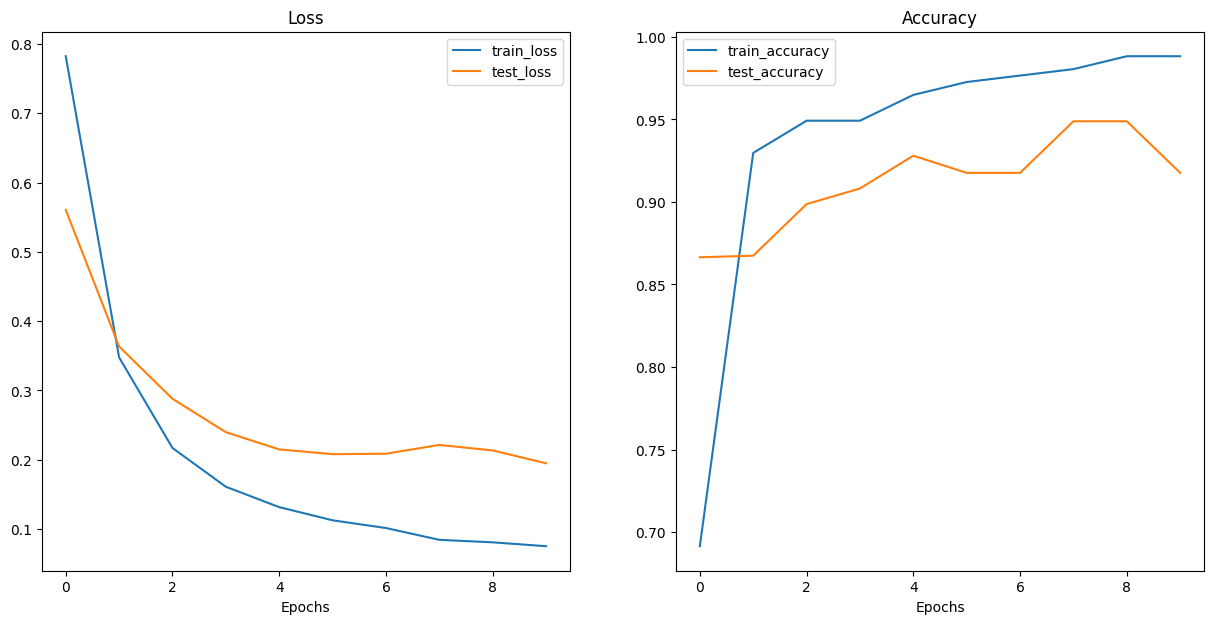

In [54]:
plot_loss_curves(pretrained_vit_results)

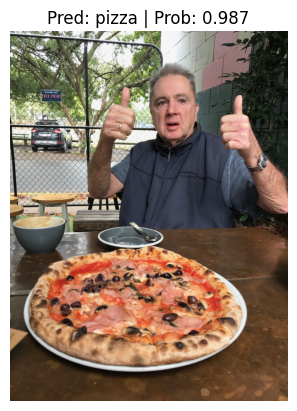

In [55]:
import requests

# Import function to make predictions on images and plot them
from going_modular.going_modular.predictions import pred_and_plot_image

# Setup custom image path
custom_image_path = image_path / "04-pizza-dad.jpeg"

# Download the image if it doesn't already exist
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        # When downloading from GitHub, need to use the "raw" file link
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

# Predict on custom image
pred_and_plot_image(model=pretrained_vit,
                    image_path=custom_image_path,
                    class_names=class_names)